In [31]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt



In [32]:
davis_df=pd.read_csv('davis.txt', 
                     sep=' ', 
                     header=None,
                     names=['Drug_ID', 'Protien_ID', 'SMILES_seq', 'AminoAcid_seq','Binding_Affinity'])

davis_filter_df=pd.read_csv('davis-filter.txt', 
                     sep=' ', 
                     header=None,
                     names=['Drug_ID', 'Protien_ID', 'SMILES_seq', 'AminoAcid_seq','Binding_Affinity'])


kiba_df=pd.read_csv('kiba.txt', 
                     sep=' ', 
                     header=None,
                     names=['Drug_ID', 'Protien_ID', 'SMILES_seq', 'AminoAcid_seq','Binding_Affinity'])



In [33]:
print("Davis dataset:")
print(f'shape:{davis_df.shape}')
#print(davis_df.head())
columns=['Drug_ID', 'Protien_ID', 'SMILES_seq', 'AminoAcid_seq','Binding_Affinity']

print(f"\nUnique Compounds:{davis_df['Drug_ID'].nunique()}")
print(f"\nUnique Targets:{davis_df['Protien_ID'].nunique()}")
print(f"Affinity_range{davis_df['Binding_Affinity'].min():.2f} - {davis_df['Binding_Affinity'].max():.2f}")
print(f"Affinity mean:{davis_df['Binding_Affinity'].mean():.2f}")



Davis dataset:
shape:(30056, 5)

Unique Compounds:68

Unique Targets:442
Affinity_range5.00 - 10.80
Affinity mean:5.45


In [34]:
print("Davis-filter dataset:")
print(f'shape:{davis_filter_df.shape}')
#print(davis_df.head())
columns=['Drug_ID', 'Protien_ID', 'SMILES_seq', 'AminoAcid_seq','Binding_Affinity']

print(f"\nUnique Compounds:{davis_filter_df['Drug_ID'].nunique()}")
print(f"\nUnique Targets:{davis_filter_df['Protien_ID'].nunique()}")
print(f"Affinity_range{davis_filter_df['Binding_Affinity'].min():.2f} - {davis_df['Binding_Affinity'].max():.2f}")
print(f"Affinity mean:{davis_filter_df['Binding_Affinity'].mean():.2f}")



Davis-filter dataset:
shape:(9125, 5)

Unique Compounds:68

Unique Targets:442
Affinity_range5.00 - 10.80
Affinity mean:6.49


In [35]:
print("Kiba dataset:")
print(f'shape:{kiba_df.shape}')
#print(davis_df.head())
columns=['Drug_ID', 'Protien_ID', 'SMILES_seq', 'AminoAcid_seq','Binding_Affinity']

print(f"\nUnique Compounds:{kiba_df['Drug_ID'].nunique()}")
print(f"\nUnique Targets:{kiba_df['Protien_ID'].nunique()}")
print(f"Affinity_range{kiba_df['Binding_Affinity'].min():.2f} - {davis_df['Binding_Affinity'].max():.2f}")
print(f"Affinity mean:{kiba_df['Binding_Affinity'].mean():.2f}")


Kiba dataset:
shape:(118254, 5)

Unique Compounds:2111

Unique Targets:229
Affinity_range0.00 - 10.80
Affinity mean:11.72


In [36]:

print(f"Affinity median: {davis_df['Binding_Affinity'].median():.2f}")
print(f"Affinity std: {davis_df['Binding_Affinity'].std():.2f}")


Affinity median: 5.00
Affinity std: 0.89


In [37]:
# Sequence lengths
davis_df['SMILES_length'] = davis_df['SMILES_seq'].str.len()
davis_df['Protein_length'] = davis_df['AminoAcid_seq'].str.len()

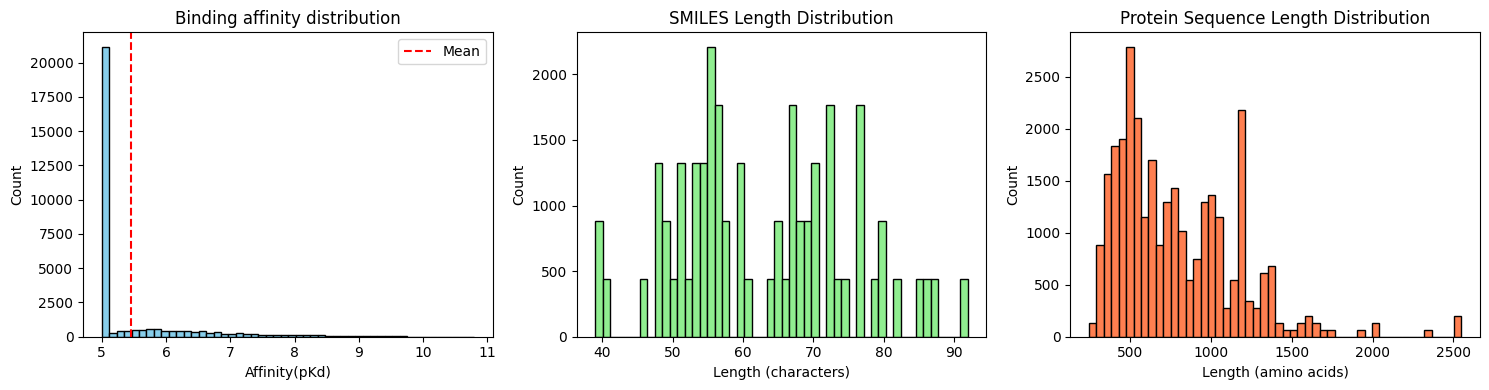

In [38]:
fig, axes=plt.subplots(1,3, figsize=(15,4))
axes[0].hist(davis_df['Binding_Affinity'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Binding affinity distribution')
axes[0].set_xlabel('Affinity(pKd)')
axes[0].set_ylabel('Count')
axes[0].axvline(davis_df['Binding_Affinity'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()


# SMILES length
axes[1].hist(davis_df['SMILES_length'], bins=50, edgecolor='black', color='lightgreen')
axes[1].set_title('SMILES Length Distribution')
axes[1].set_xlabel('Length (characters)')
axes[1].set_ylabel('Count')

#Protein length
axes[2].hist(davis_df['Protein_length'], bins=50, edgecolor='black', color='coral')
axes[2].set_title('Protein Sequence Length Distribution')
axes[2].set_xlabel('Length (amino acids)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [39]:
print(davis_df.isnull().sum())
davis_duplicated=davis_df.duplicated(subset=['SMILES_seq', 'AminoAcid_seq']).sum()
print(f'Duplicates={davis_duplicated}')



Drug_ID             0
Protien_ID          0
SMILES_seq          0
AminoAcid_seq       0
Binding_Affinity    0
SMILES_length       0
Protein_length      0
dtype: int64
Duplicates=4284


In [40]:
#!pip install rdkit
#!pip install tqdm
from rdkit import Chem
from tqdm import tqdm

def is_valid_smiles(smiles):
    try:
        mol=Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False


In [41]:
davis_df['valid_smiles']=davis_df['SMILES_seq'].apply(is_valid_smiles)
valid_count=davis_df['valid_smiles'].sum()
print(valid_count)


30056


In [42]:
davis_df.tail()
davis_df.shape

(30056, 8)

In [43]:
print(valid_count/len(davis_df['valid_smiles']))

1.0


In [44]:
valid_amino_acids = set('ACDEFGHIKLMNPQRSTVWY')
def has_only_valid_aa(sequence):
    return all(aa in valid_amino_acids for aa in sequence)

In [45]:
davis_df['valid_proteins']=davis_df['AminoAcid_seq'].apply(has_only_valid_aa)
davis_df.head()
valid_proteins=davis_df['valid_proteins'].sum()
print(valid_proteins)

29988


In [46]:
davis_df=davis_df[davis_df['valid_proteins']].copy()

In [47]:
davis_df.shape

(29988, 9)

In [48]:
davis_df.isnull().sum()

Drug_ID             0
Protien_ID          0
SMILES_seq          0
AminoAcid_seq       0
Binding_Affinity    0
SMILES_length       0
Protein_length      0
valid_smiles        0
valid_proteins      0
dtype: int64

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
train_df, test_df=train_test_split(
    davis_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)
train_df.describe()
test_df.describe()

,Drug_ID,Binding_Affinity,SMILES_length,Protein_length
count,5.998000e+03,5998.000000,5998.000000,5998.000000
mean,1.011424e+07,5.432349,62.536012,789.659553
std,1.000675e+07,0.872038,12.162398,378.278922
min,5.291000e+03,5.000000,39.000000,288.000000
25%,3.038522e+06,5.000000,53.000000,491.000000
50%,9.933475e+06,5.000000,60.000000,706.000000
75%,1.165652e+07,5.481486,72.000000,1021.000000
max,5.100435e+07,10.795880,92.000000,2549.000000


C:\Users\Divya\AppData\Local\Temp\ipykernel_1844\3039740127.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([train_df['Binding_Affinity'], test_df['Binding_Affinity']], labels=['Train', 'Test'])


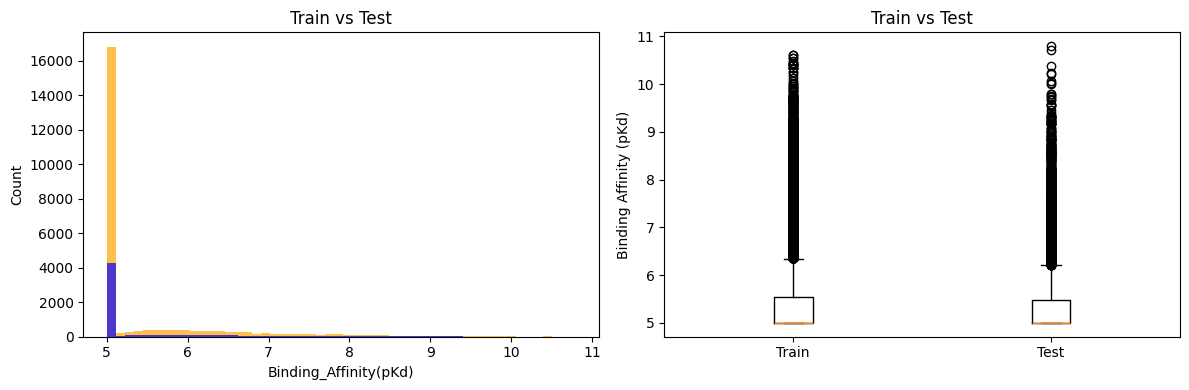

In [51]:
fig, axes= plt.subplots(1 ,2 , figsize=(12,4))
axes[0].hist(train_df['Binding_Affinity'],bins=50, alpha=0.7, label='Train', color='orange')
axes[0].hist(test_df['Binding_Affinity'], bins=50, alpha=0.7, label='Test', color='blue')
axes[0].set_xlabel('Binding_Affinity(pKd)')
axes[0].set_ylabel('Count')
axes[0].set_title('Train vs Test')

axes[1].boxplot([train_df['Binding_Affinity'], test_df['Binding_Affinity']], labels=['Train', 'Test'])
axes[1].set_ylabel('Binding Affinity (pKd)')
axes[1].set_title('Train vs Test')

plt.tight_layout()
plt.show()

In [52]:
def build_smiles_vocab(smiles_list):
    chars=set()
    for smiles in smiles_list:
        chars.update(smiles)
    
    sorted_chars=sorted(chars)
    vocab={'<PAD>':0}
    for idx, char in enumerate(sorted_chars, start =1):
        vocab[char]=idx
    return vocab

def build_protein_vocab():
    amino_acids='ACDEFGHIKLMNPQRSTVWY'
    vocab={'<PAD>':0}

    for idx, aa in enumerate(amino_acids, start=1):
        vocab[aa]=idx

    return vocab



In [53]:
smiles_vocab=build_smiles_vocab(train_df['SMILES_seq'])
protein_vocab=build_protein_vocab()

In [54]:
print(len(protein_vocab))

21


In [55]:
max_smiles_length=max(train_df['SMILES_length'].max(), test_df['SMILES_length'].max())
max_protein_length=max(train_df['Protein_length'].max(), test_df['Protein_length'].max())

smiles_max_length=min(120, int(max_smiles_length)*1.1)
protein_max_length=min(1200, int(max_protein_length)*1.1)

In [56]:
#Encoding
def encode_smiles(smiles, vocab, max_length):
    encoded=[vocab.get(char, 0) for char in smiles]

    if len(encoded)< max_length:
        encoded+= [0] * (max_length-len(encoded))
    
    else:
        encoded=encoded[:max_length]
    return encoded

In [57]:
def encode_proteins(protein, vocab, max_length):
    encoded=[vocab.get(char, 0) for char in protein]

    if len(encoded)<max_length:
        encoded+=[0]* (max_length-len(encoded))
    
    else:
        encoded=encoded[:max_length]

    return encoded

In [58]:
X_drug_train=np.array([encode_smiles(smiles, smiles_vocab, max_smiles_length) 
                       for smiles in train_df['SMILES_seq']])
X_protein_train=np.array([encode_proteins(protein, protein_vocab, max_protein_length) 
                       for protein in train_df['AminoAcid_seq']])
Y_train=train_df['Binding_Affinity'].values


In [59]:
X_drug_test=np.array([encode_smiles(smiles, smiles_vocab, max_smiles_length) 
                       for smiles in test_df['SMILES_seq']])
X_protein_test=np.array([encode_proteins(protein, protein_vocab, max_protein_length) 
                       for protein in test_df['AminoAcid_seq']])
Y_test=test_df['Binding_Affinity'].values


In [60]:
sample_smiles=train_df['SMILES_seq'].iloc[0]
sample_encoded=X_drug_train[0]
print(sample_smiles)
print(sample_encoded)

CC(C(=O)O)O.CN1CCN(CC1)C2=CC3=C(C=C2)NC(=C4C(=C5C(=NC4=O)C=CC=C5F)N)N3.O
[16 16  2 16  2 14 20  3 20  3 20  4 16 19  5 16 16 19  2 16 16  5  3 16
  6 14 16 16  7 14 16  2 16 14 16  6  3 19 16  2 14 16  8 16  2 14 16  9
 16  2 14 19 16  8 14 20  3 16 14 16 16 14 16  9 17  3 19  3 19  7  4 20
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


In [68]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_dti_model(drug_vocab_size, protein_vocab_size, drug_max_len, protein_max_len):
    
    # --- Drug Branch ---
    drug_input = layers.Input(shape=(drug_max_len,), name='drug_input')
    drug_embedding = layers.Embedding(input_dim=drug_vocab_size, output_dim=128,
                                       input_length=drug_max_len, name='drug_embedding')(drug_input)
    drug_flatten = layers.Flatten(name='drug_flatten')(drug_embedding)
    drug_dense = layers.Dense(256, activation='relu', name='drug_dense')(drug_flatten)
    drug_dropout = layers.Dropout(0.3, name='drug_dropout')(drug_dense)

    # --- Protein Branch ---
    protein_input = layers.Input(shape=(protein_max_len,), name='protein_input')
    protein_embedding = layers.Embedding(input_dim=protein_vocab_size, output_dim=128,
                                          input_length=protein_max_len, name='protein_embedding')(protein_input)
    protein_flatten = layers.Flatten(name='protein_flatten')(protein_embedding)
    protein_dense = layers.Dense(256, activation='relu', name='protein_dense')(protein_flatten)  # ✅ fix 1
    protein_dropout = layers.Dropout(0.3, name='protein_dropout')(protein_dense)

    # --- Merge ---
    print("Merging branches...")
    merged = layers.Concatenate(name='concatenate')([drug_dropout, protein_dropout])  # ✅ fix 2

    # --- Fully Connected Layers ---
    fc1 = layers.Dense(512, activation='relu', name='fc1')(merged)
    dropout1 = layers.Dropout(0.3, name='dropout1')(fc1)
    fc2 = layers.Dense(256, activation='relu', name='fc2')(dropout1)
    dropout2 = layers.Dropout(0.3, name='dropout2')(fc2)               # ✅ fix 3
    fc3 = layers.Dense(128, activation='relu', name='fc3')(dropout2)   # ✅ fix 4
    output = layers.Dense(1, name='output')(fc3)

    model = keras.Model(inputs=[drug_input, protein_input], outputs=output, name='DTI_predictor')
    return model

# Build it
model = build_dti_model(
    drug_vocab_size=len(smiles_vocab),
    protein_vocab_size=len(protein_vocab),
    drug_max_len=int(smiles_max_length),        # ✅ force integer
    protein_max_len=int(protein_max_length)  
)

model.summary()


Merging branches...


C:\Users\Divya\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "DTI_predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ drug_input          │ (None, 101)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_input       │ (None, 1200)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_embedding      │ (None, 101, 128)  │      3,200 │ drug_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_embedding   │ (None, 1200, 128) │      2,688 │ protein_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_flatten        │ (None, 12928)     │          0 │ drug_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_flatten     │ (None, 153600)    │          0 │ protein_embeddin… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_dense (Dense)  │ (None, 256)       │  3,309,824 │ drug_flatten[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_dense       │ (None, 256)       │ 39,321,856 │ protein_flatten[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_dropout        │ (None, 256)       │          0 │ drug_dense[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_dropout     │ (None, 256)       │          0 │ protein_dense[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ drug_dropout[0][… │
│ (Concatenate)       │                   │            │ protein_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 512)       │    262,656 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 512)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 256)       │    131,328 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout2 (Dropout)  │ (None, 256)       │          0 │ fc2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc3 (Dense)         │ (None, 128)       │     32,896 │ dropout2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ fc3[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 43,064,577 (164.28 MB)

 Trainable params: 43,064,577 (164.28 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
# Step 1: Check actual shapes
print(X_drug_train.shape)
print(X_protein_train.shape)

(23990, 92)
(23990, 2549)


In [71]:
# Step 2: Redefine lengths from actual data
smiles_max_length = X_drug_train.shape[1]
protein_max_length = X_protein_train.shape[1]

# Step 3: Rebuild model with correct lengths
model = build_dti_model(
    drug_vocab_size=len(smiles_vocab),
    protein_vocab_size=len(protein_vocab),
    drug_max_len=smiles_max_length,
    protein_max_len=protein_max_length
)

# Step 4: Recompile
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Ready to train!")

Merging branches...
Ready to train!


In [72]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

os.makedirs('models', exist_ok=True)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

callbacks=[
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath='models/dti_best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]
history=model.fit(
    [X_drug_train, X_protein_train], Y_train, validation_split=0.1, epochs=100, batch_size=256, callbacks=callbacks, verbose=1)





Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - loss: 693.5861 - mae: 14.9163
Epoch 1: val_loss improved from None to 3.47341, saving model to models/dti_best_model.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 76s 860ms/step - loss: 276.2776 - mae: 7.3945 - val_loss: 3.4734 - val_mae: 1.5814 - learning_rate: 0.0010
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 2.4268 - mae: 1.1880
Epoch 2: val_loss improved from 3.47341 to 3.05333, saving model to models/dti_best_model.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - loss: 2.0638 - mae: 1.0887 - val_loss: 3.0533 - val_mae: 1.5329 - learning_rate: 0.0010
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 1.4880 - mae: 0.9210
Epoch 3: val_loss improved from 3.05333 to 2.98795, saving model to models/dti_best_model.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - loss: 1.4682 - mae: 0.9112 - val_loss: 2.9879 - val_mae: 1.5304 - learning_rate: 0.0010
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 1.3452 - mae: 0.8699

In [73]:
def build_dti_model(drug_vocab_size, protein_vocab_size, drug_max_len, protein_max_len):
    
    # --- Drug Branch ---
    drug_input = layers.Input(shape=(drug_max_len,), name='drug_input')
    drug_embedding = layers.Embedding(input_dim=drug_vocab_size, output_dim=128,
                                       input_length=drug_max_len, name='drug_embedding')(drug_input)
    drug_conv = layers.Conv1D(64, kernel_size=3, activation='relu', name='drug_conv')(drug_embedding)
    drug_pool = layers.GlobalMaxPooling1D(name='drug_pool')(drug_conv)
    drug_dense = layers.Dense(128, activation='relu', name='drug_dense')(drug_pool)
    drug_dropout = layers.Dropout(0.3, name='drug_dropout')(drug_dense)

    # --- Protein Branch ---
    protein_input = layers.Input(shape=(protein_max_len,), name='protein_input')
    protein_embedding = layers.Embedding(input_dim=protein_vocab_size, output_dim=128,
                                          input_length=protein_max_len, name='protein_embedding')(protein_input)
    protein_conv = layers.Conv1D(64, kernel_size=3, activation='relu', name='protein_conv')(protein_embedding)
    protein_pool = layers.GlobalMaxPooling1D(name='protein_pool')(protein_conv)
    protein_dense = layers.Dense(128, activation='relu', name='protein_dense')(protein_pool)
    protein_dropout = layers.Dropout(0.3, name='protein_dropout')(protein_dense)

    # --- Merge ---
    merged = layers.Concatenate(name='concatenate')([drug_dropout, protein_dropout])

    # --- Fully Connected ---
    fc1 = layers.Dense(256, activation='relu', name='fc1')(merged)
    dropout1 = layers.Dropout(0.4, name='dropout1')(fc1)
    fc2 = layers.Dense(128, activation='relu', name='fc2')(dropout1)
    dropout2 = layers.Dropout(0.4, name='dropout2')(fc2)
    output = layers.Dense(1, name='output')(dropout2)

    model = keras.Model(inputs=[drug_input, protein_input], outputs=output, name='DTI_predictor')
    return model

# Rebuild and recompile
model = build_dti_model(
    drug_vocab_size=len(smiles_vocab),
    protein_vocab_size=len(protein_vocab),
    drug_max_len=smiles_max_length,
    protein_max_len=protein_max_length
)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "DTI_predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ drug_input          │ (None, 92)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_input       │ (None, 2549)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_embedding      │ (None, 92, 128)   │      3,200 │ drug_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_embedding   │ (None, 2549, 128) │      2,688 │ protein_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_conv (Conv1D)  │ (None, 90, 64)    │     24,640 │ drug_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_conv        │ (None, 2547, 64)  │     24,640 │ protein_embeddin… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_pool           │ (None, 64)        │          0 │ drug_conv[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_pool        │ (None, 64)        │          0 │ protein_conv[0][… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_dense (Dense)  │ (None, 128)       │      8,320 │ drug_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_dense       │ (None, 128)       │      8,320 │ protein_pool[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drug_dropout        │ (None, 128)       │          0 │ drug_dense[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ protein_dropout     │ (None, 128)       │          0 │ protein_dense[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ drug_dropout[0][… │
│ (Concatenate)       │                   │            │ protein_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 256)       │     65,792 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 256)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 128)       │     32,896 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout2 (Dropout)  │ (None, 128)       │          0 │ fc2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout2[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 170,625 (666.50 KB)

 Trainable params: 170,625 (666.50 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

os.makedirs('models', exist_ok=True)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

callbacks=[
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath='models/dti_best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
]
history=model.fit(
    [X_drug_train, X_protein_train], Y_train, validation_split=0.1, epochs=100, batch_size=256, callbacks=callbacks, verbose=1)



Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 9.0573 - mae: 2.3129
Epoch 1: val_loss improved from None to 0.73339, saving model to models/dti_best_model.keras
85/85 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - loss: 4.0349 - mae: 1.4471 - val_loss: 0.7334 - val_mae: 0.5805 - learning_rate: 0.0010
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 1.4802 - mae: 0.9159
Epoch 2: val_loss did not improve from 0.73339
85/85 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - loss: 1.3776 - mae: 0.8780 - val_loss: 0.9287 - val_mae: 0.6004 - learning_rate: 0.0010
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 1.2215 - mae: 0.8159
Epoch 3: val_loss did not improve from 0.73339
85/85 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - loss: 1.1861 - mae: 0.8107 - val_loss: 1.1643 - val_mae: 0.7648 - learning_rate: 0.0010
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 1.1376 - mae: 0.7896
Epoch 4: val_loss did not improve from 0.73339
85/85 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - loss: 1.1201 - mae

In [78]:
import numpy as np
from scipy import stats

# Predictions
y_pred = model.predict([X_drug_test, X_protein_test]).flatten()

# Metrics
test_loss, test_mae = model.evaluate([X_drug_test, X_protein_test], Y_test, verbose=0)
rmse = np.sqrt(test_loss)
pearson_r, p_value = stats.pearsonr(Y_test, y_pred)

print(f"Test MSE:  {test_loss:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Pearson r: {pearson_r:.4f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Test MSE:  0.4281
Test RMSE: 0.6543
Test MAE:  0.4008
Pearson r: 0.6613


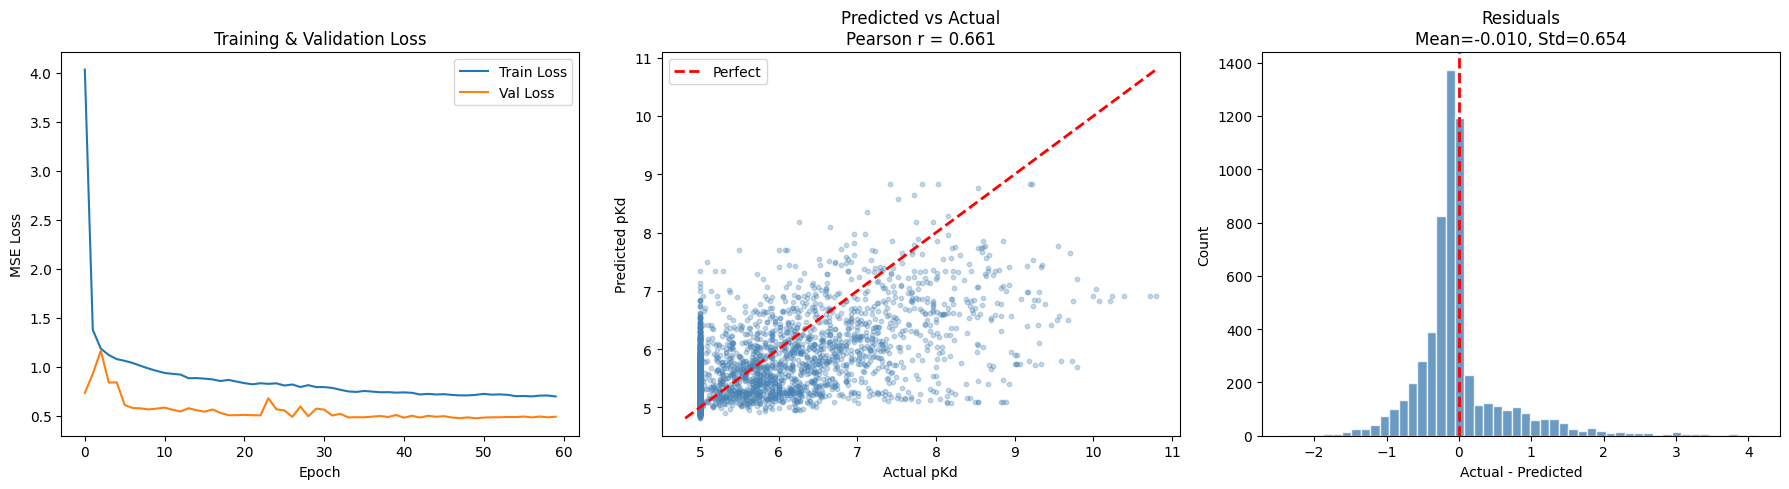

Model saved!


In [80]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss curves
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# Plot 2: Predicted vs Actual
axes[1].scatter(Y_test, y_pred, alpha=0.3, s=10, color='steelblue')
min_val, max_val = min(Y_test.min(), y_pred.min()), max(Y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
axes[1].set_xlabel('Actual pKd')
axes[1].set_ylabel('Predicted pKd')
axes[1].set_title(f'Predicted vs Actual\nPearson r = {pearson_r:.3f}')
axes[1].legend()

# Plot 3: Residuals
residuals = Y_test - y_pred
axes[2].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_title(f'Residuals\nMean={residuals.mean():.3f}, Std={residuals.std():.3f}')
axes[2].set_xlabel('Actual - Predicted')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('dti_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Save model
model.save('models/dti_final_model.keras')
print("Model saved!")

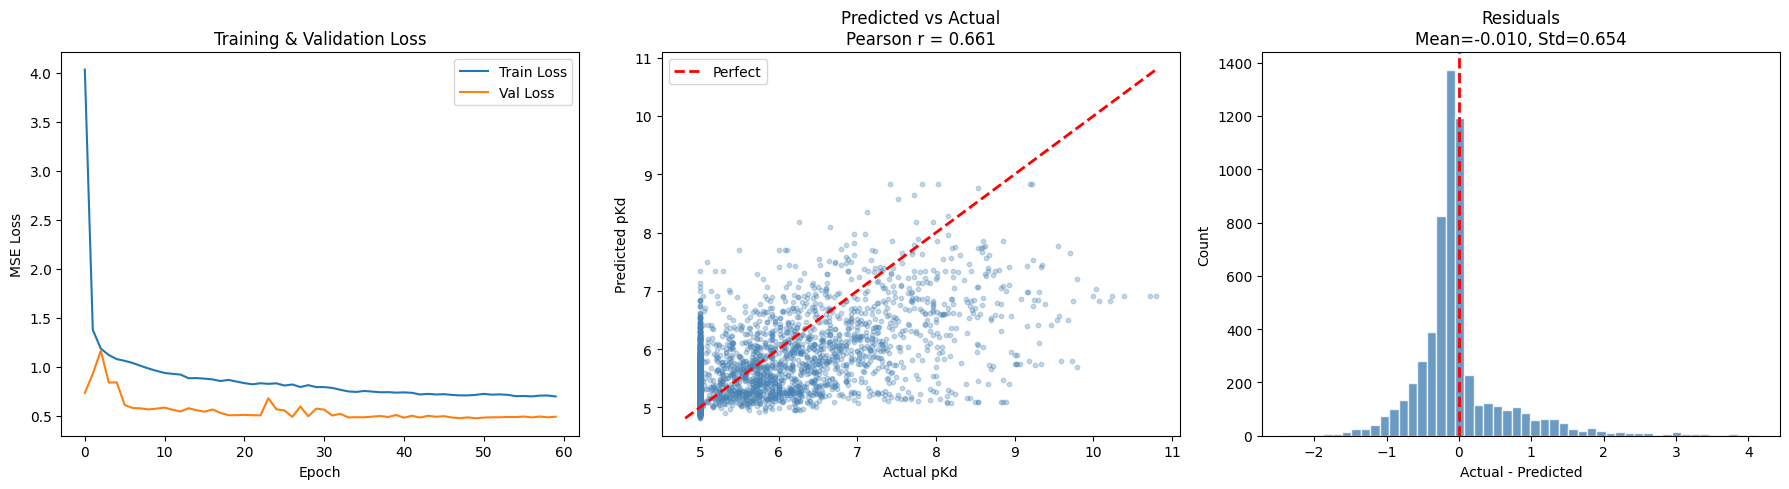

Done! Model saved!


In [81]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss curves
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

# Plot 2: Predicted vs Actual
axes[1].scatter(Y_test, y_pred, alpha=0.3, s=10, color='steelblue')
min_val = min(Y_test.min(), y_pred.min())
max_val = max(Y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
axes[1].set_xlabel('Actual pKd')
axes[1].set_ylabel('Predicted pKd')
axes[1].set_title(f'Predicted vs Actual\nPearson r = {pearson_r:.3f}')
axes[1].legend()

# Plot 3: Residuals
residuals = Y_test - y_pred
axes[2].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_title(f'Residuals\nMean={residuals.mean():.3f}, Std={residuals.std():.3f}')
axes[2].set_xlabel('Actual - Predicted')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('dti_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Save model
model.save('models/dti_final_model.keras')
print("Done! Model saved!")